In [6]:
# !pip install dtaidistance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 24.5 MB/s eta 0:00:00


In [118]:
from dtaidistance import dtw
from dtaidistance import dtw_visualisation as dtwvis
import random
import numpy as np

# **DATA 1:**

(<Figure size 1000x1000 with 4 Axes>, [<Axes: >, <Axes: >, <Axes: >, <Axes: >])

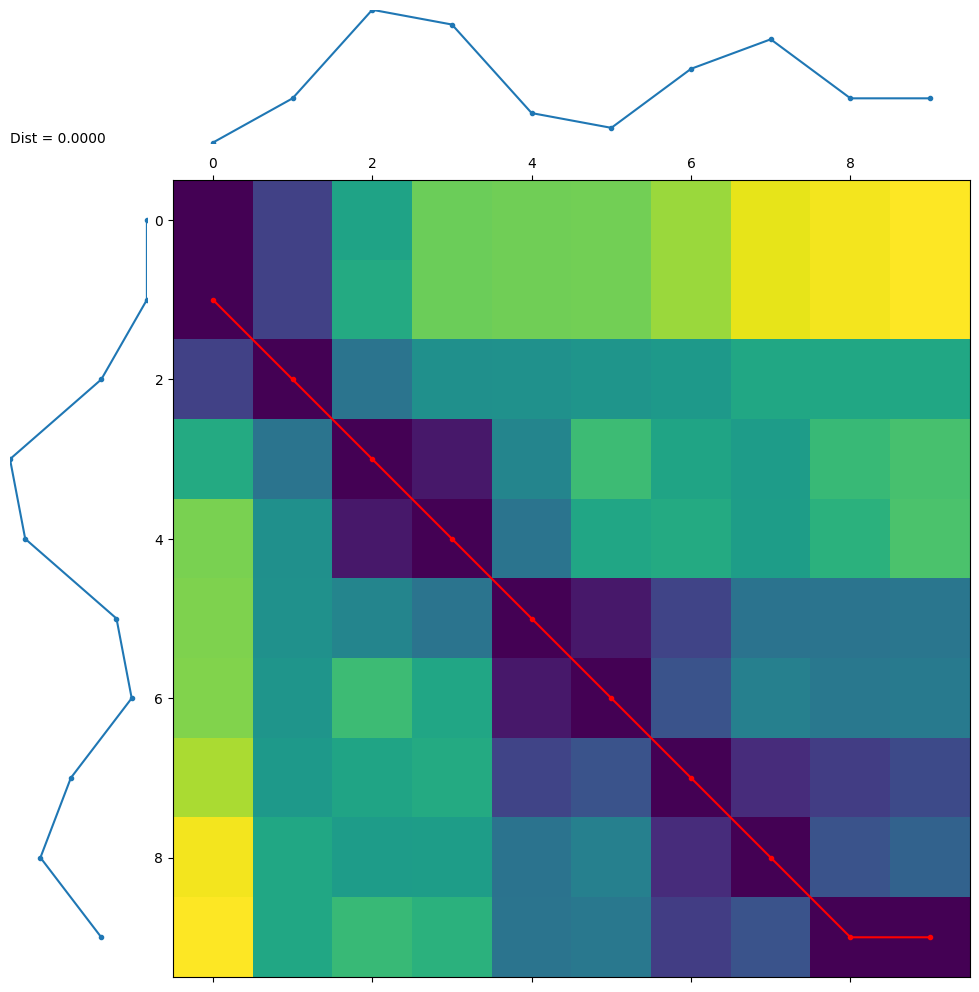

In [119]:
s1 = np.array([1,1,4,10,9,3,2,6,8,4])
s2 = np.array([1,4,10,9,3,2,6,8,4,4])

random.seed(1)

for idx in range(len(s2)):
    if random.random() < 0.05:
        s2[idx] += (random.random() - 0.5) / 2

d, paths = dtw.warping_paths(s1, s2, window=25, psi=2)
best_path = dtw.best_path(paths)
dtwvis.plot_warpingpaths(s1, s2, paths, best_path)

In [120]:
d, cost_matrix = dtw.warping_paths(s1, s2, window=25, psi=2)

print("DTW Distance:", d)

print("Accumulated Cost Matrix:")
print(cost_matrix)

DTW Distance: 0.0
Accumulated Cost Matrix:
[[ 0.          0.          0.                 inf         inf         inf
          inf         inf         inf         inf         inf]
 [ 0.          0.          3.          9.         12.04159458 12.20655562
  12.24744871 13.22875656 14.96662955 15.26433752 15.55634919]
 [ 0.          0.          3.          9.48683298 12.04159458 12.20655562
  12.24744871 13.22875656 14.96662955 15.26433752 15.55634919]
 [        inf  3.          0.          6.          7.81024968  7.87400787
   8.1240384   8.36660027  9.2736185   9.2736185   9.2736185 ]
 [        inf  9.48683298  6.          0.          1.          7.07106781
  10.67707825  9.05538514  8.60232527 10.48808848 11.04536102]
 [        inf 12.40967365  7.81024968  1.          0.          6.
   9.21954446  9.53939201  8.66025404  9.94987437 11.13552873]
 [        inf 12.56980509  7.87400787  7.07106781  6.          0.
   1.          3.16227766  5.91607978  6.          6.08276253]
 [        inf 

In [121]:
distance = dtw.distance(s1, s2)
print(distance)

0.0


# **DATA 2:**

(<Figure size 1000x1000 with 4 Axes>, [<Axes: >, <Axes: >, <Axes: >, <Axes: >])

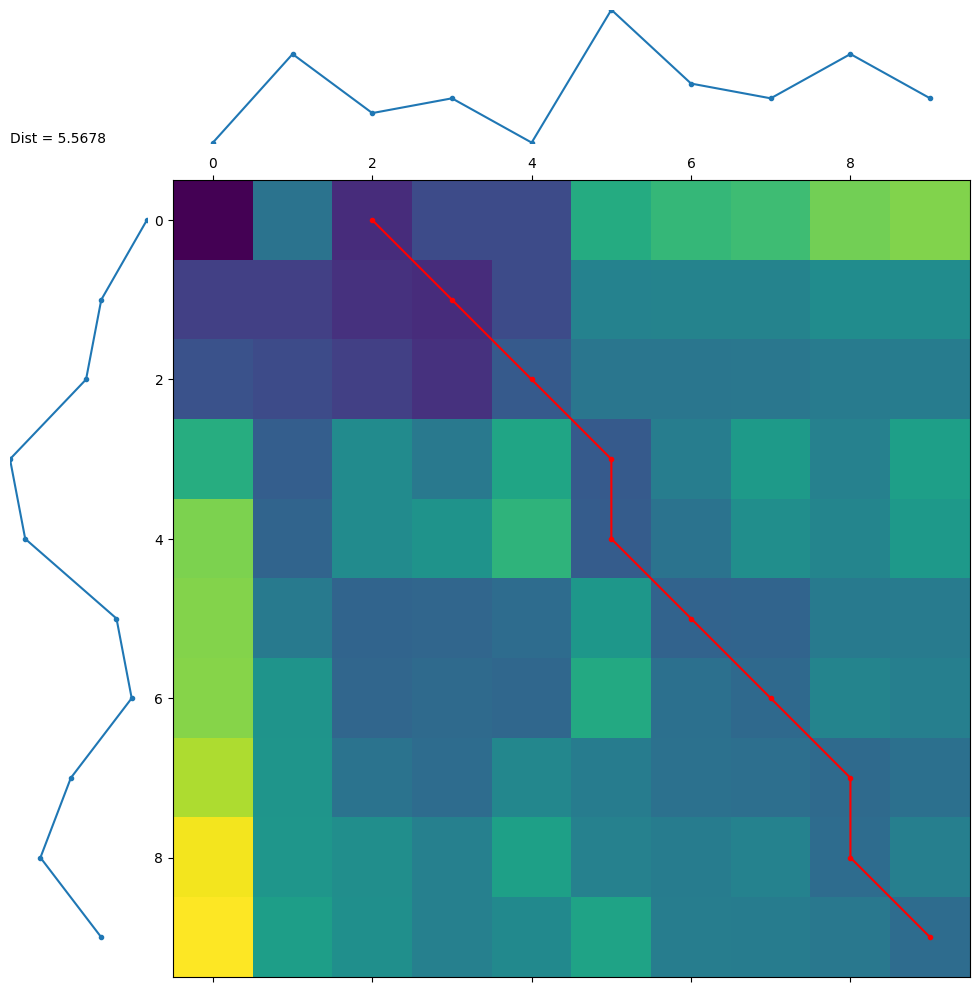

In [122]:
s1 = np.array([1,4,5,10,9,3,2,6,8,4])
s2 = np.array([1,7,3,4,1,10,5,4,7,4])
random.seed(1)
for idx in range(len(s2)):
    if random.random() < 0.05:
        s2[idx] += (random.random() - 0.5) / 2
d, paths = dtw.warping_paths(s1, s2, window=25, psi=2)
best_path = dtw.best_path(paths)
dtwvis.plot_warpingpaths(s1, s2, paths, best_path)

In [123]:
d, cost_matrix = dtw.warping_paths(s1, s2, window=25, psi=2)

print("DTW Distance:", d)

print("Accumulated Cost Matrix:")
print(cost_matrix)

DTW Distance: 5.5677643628300215
Accumulated Cost Matrix:
[[ 0.          0.          0.                 inf         inf         inf
          inf         inf         inf         inf         inf]
 [ 0.          0.          6.          2.          3.60555128  3.60555128
   9.69535971 10.48808848 10.90871211 12.4498996  12.80624847]
 [ 0.          3.          3.          2.23606798  2.          3.60555128
   7.          7.07106781  7.07106781  7.68114575  7.68114575]
 [        inf  4.          3.60555128  3.          2.23606798  4.47213595
   6.164414    6.164414    6.244998    6.55743852  6.63324958]
 [        inf  9.8488578   4.69041576  7.61577311  6.40312424  9.2736185
   4.47213595  6.70820393  8.60232527  6.92820323  8.88819442]
 [        inf 12.68857754  5.09901951  7.61577311  8.1240384  10.24695077
   4.58257569  6.          7.81024968  7.21110255  8.54400375]
 [        inf 12.84523258  6.4807407   5.09901951  5.19615242  5.56776436
   8.36660027  5.          5.09901951  6.480740

In [124]:
distance = dtw.distance(s1, s2)
print(distance)

6.082762530298219


# **AIR PASSENGERS DATASET**

In [125]:
from google.colab import drive
drive.mount("/content/drive")

import pandas as pd
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [126]:
file_path = "/content/drive/MyDrive/Colab Notebooks/CSV DATASET FILES/AirPassengers.csv"

In [127]:
df = pd.read_csv(file_path)
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [128]:
data = df["Passengers"].values

s1 = data[0:50]
s2 = data[50:100]

random.seed(1)
for idx in range(len(s2)):
    if random.random() < 0.05:
        s2[idx] += (random.random() - 0.5) / 2

distance = dtw.distance(s1, s2)
print(f"DTW distance between segments: {distance:.2f}")

DTW distance between segments: 635.26


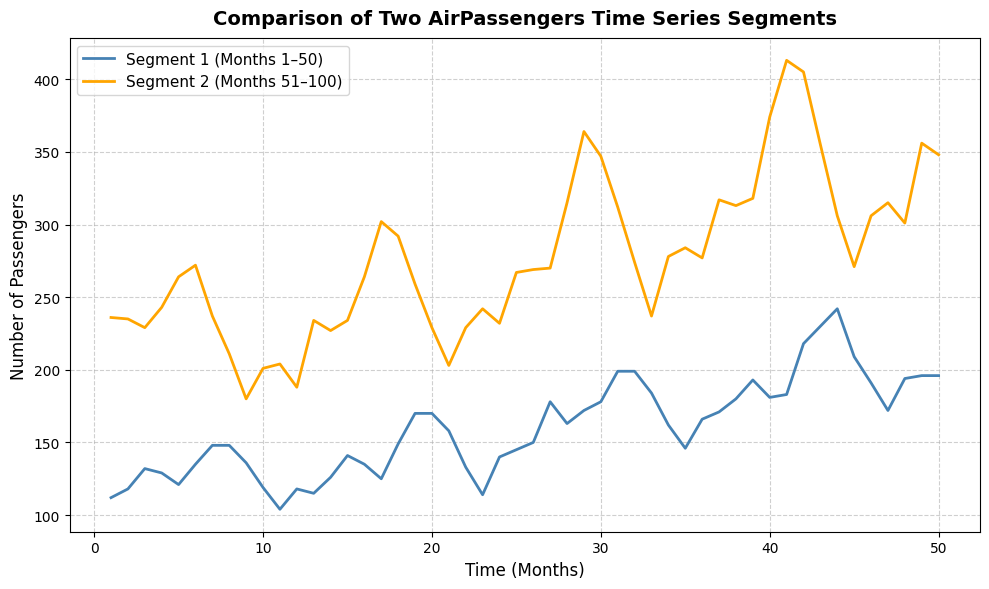

In [129]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(s1)+1), s1, label="Segment 1 (Months 1–50)", color='steelblue', linewidth=2)
plt.plot(range(1, len(s2)+1), s2, label="Segment 2 (Months 51–100)", color='orange', linewidth=2)

plt.title("Comparison of Two AirPassengers Time Series Segments", fontsize=14, fontweight='bold', pad=10)
plt.xlabel("Time (Months)", fontsize=12)
plt.ylabel("Number of Passengers", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [130]:
d, cost_matrix = dtw.warping_paths(s1, s2, window=25, psi=2)

print("DTW Distance:", d)

print("Accumulated Cost Matrix:")
print(cost_matrix)


DTW Distance: 611.6036298126427
Accumulated Cost Matrix:
[[  0.           0.           0.         ...          inf          inf
           inf]
 [  0.         124.         123.         ...          inf          inf
           inf]
 [  0.         118.         166.17159805 ...          inf          inf
           inf]
 ...
 [         inf          inf          inf ... 604.35999206 620.3184666
  634.13642065]
 [         inf          inf          inf ... 608.39953978 625.18077386
  638.6697112 ]
 [         inf          inf          inf ... 611.60362981  -1.
   -1.        ]]


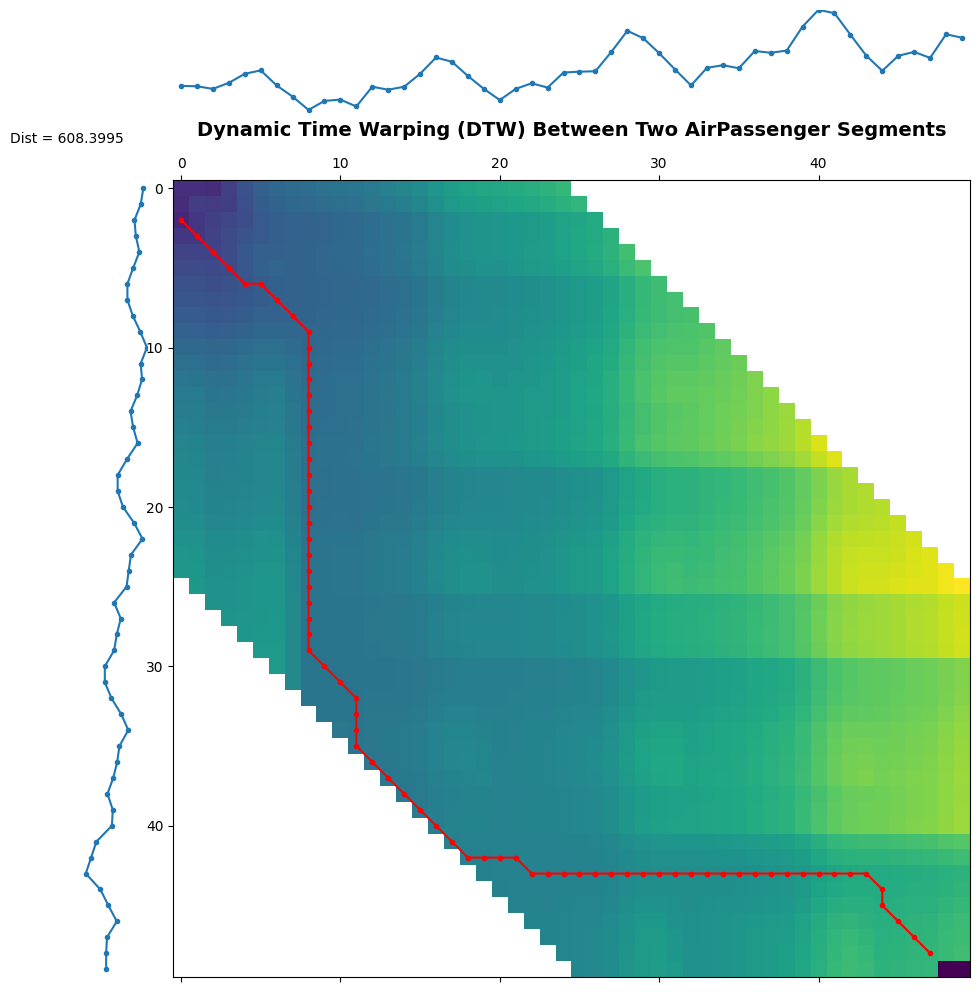

In [131]:
d, paths = dtw.warping_paths(s1, s2, window=25, psi=2)
best_path = dtw.best_path(paths)

dtwvis.plot_warpingpaths(s1, s2, paths, best_path)

plt.title("Dynamic Time Warping (DTW) Between Two AirPassenger Segments", fontsize=14, fontweight='bold', pad=15)
plt.show()

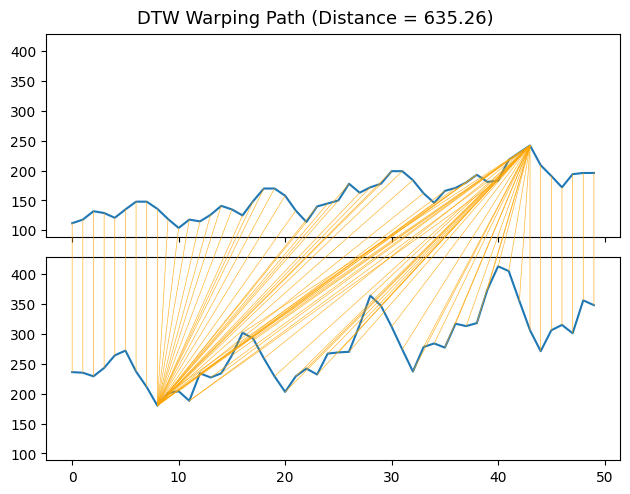

In [132]:
path = dtw.warping_path(s1, s2)

dtwvis.plot_warping(s1, s2, path)
plt.suptitle(f"DTW Warping Path (Distance = {distance:.2f})", fontsize=13, y = 1.02)
plt.show()